# Phase 3 : Modèle SABR sur Données Synthétiques

Ce notebook aborde l'objectif "Bon" de notre projet : l'implémentation et l'inférence du modèle SABR (Stochastic Alpha Beta Rho). 

Contrairement au modèle de Heston qui modélise le prix au comptant, le SABR modélise directement le taux forward $F_t$ et sa volatilité stochastique $\alpha_t$.

## 1. Équations du Modèle
Le modèle est régi par le système suivant :
$$dF_t = \alpha_t F_t^\beta dW_t^F$$
$$d\alpha_t = \nu \alpha_t dW_t^\alpha$$
$$dW_t^F \cdot dW_t^\alpha = \rho dt$$

**Paramètres clés :**
* $\alpha_0$ : Volatilité initiale
* $\beta$ : Élasticité (0 = log-normal, 0.5 = CIR, 1 = normal)
* $\nu$ : Volatilité de la volatilité (Vol of Vol)
* $\rho$ : Corrélation

## 2. Objectifs du Notebook
1. Générer des trajectoires SABR avec la méthode d'Euler-Maruyama (et une dynamique log-normale exacte pour la volatilité).
2. Estimer les paramètres avec notre moteur MCMC (NUTS) via une paramétrisation non-centrée.
3. Analyser la convergence et comparer brièvement avec Heston.

In [1]:
# Commandes magiques pour éviter le piège du cache Jupyter !
%load_ext autoreload
%autoreload 2

import sys
import os
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from src.simulation.sabr_sim import SABRSimulator
from src.models.sabr_model import SABRModel
from src.inference.mcmc_sampler import MCMCSampler, MCMCSamplerConfig
from src.inference.diagnostics import MCMCDiagnostics

# Configuration visuelle
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 3. Génération des Données Synthétiques

Nous simulons un environnement de taux d'intérêt sur 4 ans pour fournir suffisamment de données statistiques à notre échantillonneur MCMC.

In [2]:
# Vrais paramètres cibles pour un environnement de taux
true_params_sabr = {
    'F0': 0.05,        # Taux forward initial à 5%
    'alpha0': 0.2,     # Volatilité initiale
    'beta': 0.5,       # Dynamique de type CIR (standard pour les taux)
    'nu': 0.4,         # Vol of vol
    'rho': -0.5        # Corrélation négative
}

# On génère 4 ans de données (T=4.0) pour assurer la convergence statistique
simulator = SABRSimulator(**true_params_sabr, T=4.0, dt=1/252, seed=42)
F, alpha, t = simulator.simulate(n_paths=1)

print(f"Données générées : {len(t)} pas de temps.")
print(f"Taux Forward final : {F[-1, 0]:.4f}")

Données générées : 1009 pas de temps.
Taux Forward final : 0.0266


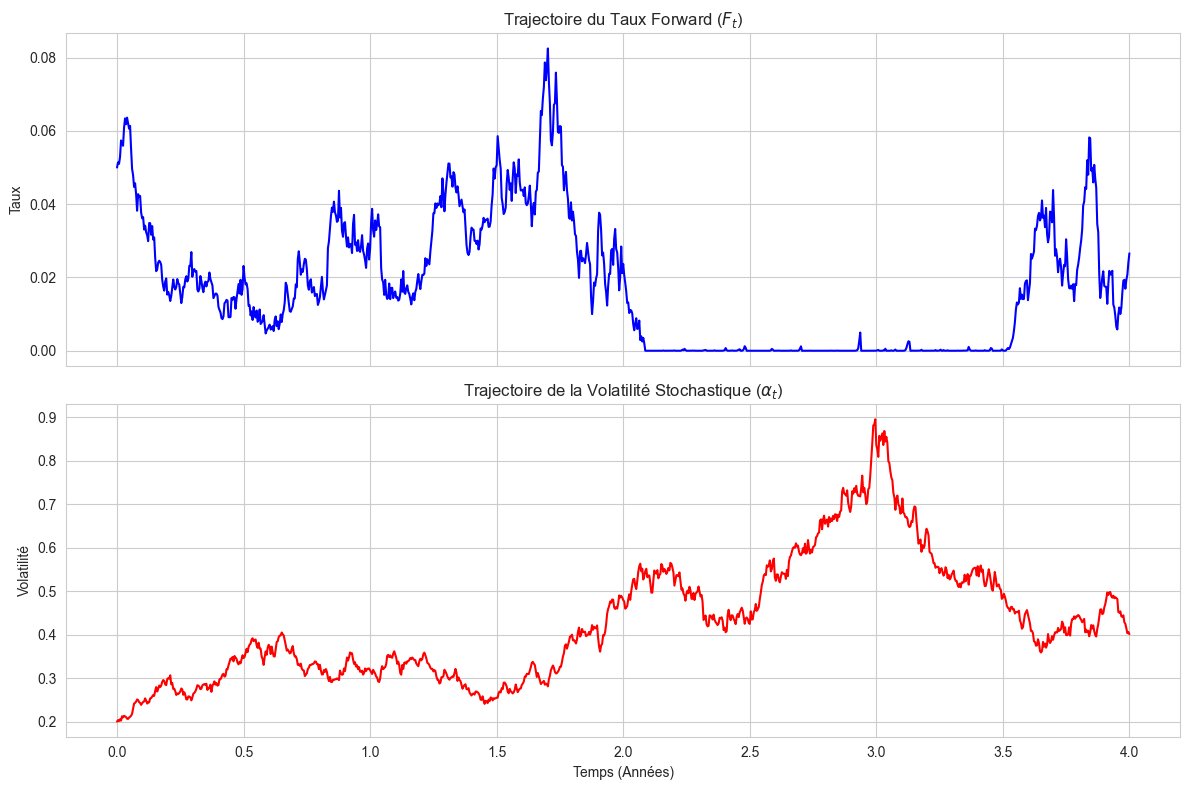

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(t, F[:, 0], color='blue', linewidth=1.5)
ax1.set_title('Trajectoire du Taux Forward ($F_t$)')
ax1.set_ylabel('Taux')

ax2.plot(t, alpha[:, 0], color='red', linewidth=1.5)
ax2.set_title('Trajectoire de la Volatilité Stochastique ($\\alpha_t$)')
ax2.set_ylabel('Volatilité')
ax2.set_xlabel('Temps (Années)')

plt.tight_layout()
plt.show()

## 4. Inférence MCMC (Algorithme NUTS)

Nous utilisons ici le modèle probabiliste `SABRModel` avec paramétrisation non-centrée (variables latentes $Z_\alpha$) pour garantir une exploration robuste de l'espace des paramètres.

In [4]:
# 1. Préparation des données (Transposition pour le modèle)
F_obs = F.T

# 2. Instanciation du modèle NumPyro
sabr_model = SABRModel(dt=1/252)

# 3. Configuration de l'échantillonneur
config = MCMCSamplerConfig.get_high_quality_config()
sampler = MCMCSampler(model=sabr_model.model, **config)

# 4. Exécution (Prenez un café, l'exploration latente prend du temps)
rng_key = jax.random.PRNGKey(123)
print("Début de l'inférence MCMC sur le modèle SABR...")
samples = sampler.run(rng_key, F_obs=F_obs)

Début de l'inférence MCMC sur le modèle SABR...
Configuration MCMC:
  Warm-up: 2000
  Samples: 4000
  Chains: 4
  Chain method: parallel
  Target accept prob: 0.95
  Max tree depth: 12
  Init strategy: adapt_diag

Démarrage de l'inférence MCMC...


c:\Users\Benoi\Finance\2026-ECE-Ing4-Fin-IA-Projet2-Gr03\2026-ECE-Ing4-Fin-IA-Projet2-Gr03\A.4 Modélisation de volatilté stochastique (Heston\SABR) avec MCMC\src\inference\mcmc_sampler.py:78: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  self.mcmc = MCMC(
sample: 100%|██████████| 6000/6000 [00:54<00:00, 109.63it/s, 127 steps of size 2.82e-02. acc. prob=0.96]


Inférence terminée en 261.91 secondes

=== DEBUG: Structure des échantillons ===
alpha0: shape = (4, 4000), ndim = 2
beta: shape = (4, 4000), ndim = 2
nu: shape = (4, 4000), ndim = 2
rho: shape = (4, 4000), ndim = 2
=== FIN DEBUG ===



In [5]:
# Affichage de la comparaison avec les vrais paramètres
sampler.print_comparison(true_params_sabr)

# Calcul et affichage des diagnostics
diagnostics = MCMCDiagnostics(samples)
print(diagnostics.get_convergence_report())

COMPARAISON AVEC LES VRAIS PARAMÈTRES

alpha0:
  Vrai: 0.200000
  Estimé: 0.223124
  Erreur: 0.023124
  Erreur relative: 11.56%
  Dans IC 95%: ✓

beta:
  Vrai: 0.500000
  Estimé: 0.499805
  Erreur: -0.000195
  Erreur relative: 0.04%
  Dans IC 95%: ✓

nu:
  Vrai: 0.400000
  Estimé: 0.483462
  Erreur: 0.083462
  Erreur relative: 20.87%
  Dans IC 95%: ✓

rho:
  Vrai: -0.500000
  Estimé: -0.102223
  Erreur: 0.397777
  Erreur relative: 79.56%
  Dans IC 95%: ✗

RAPPORT DE CONVERGENCE MCMC

✗ CONVERGENCE INSUFFISANTE

Détails par paramètre:
--------------------------------------------------------------------------------

alpha0:
  R-hat: 1.0224 ✓
  ESS: 3526 ✓

beta:
  R-hat: 1.1233 ✗
  ESS: 2368 ✓

nu:
  R-hat: 1.2849 ✗
  ESS: 1694 ✓

rho:
  R-hat: 1.8386 ✗
  ESS: 277 ✗




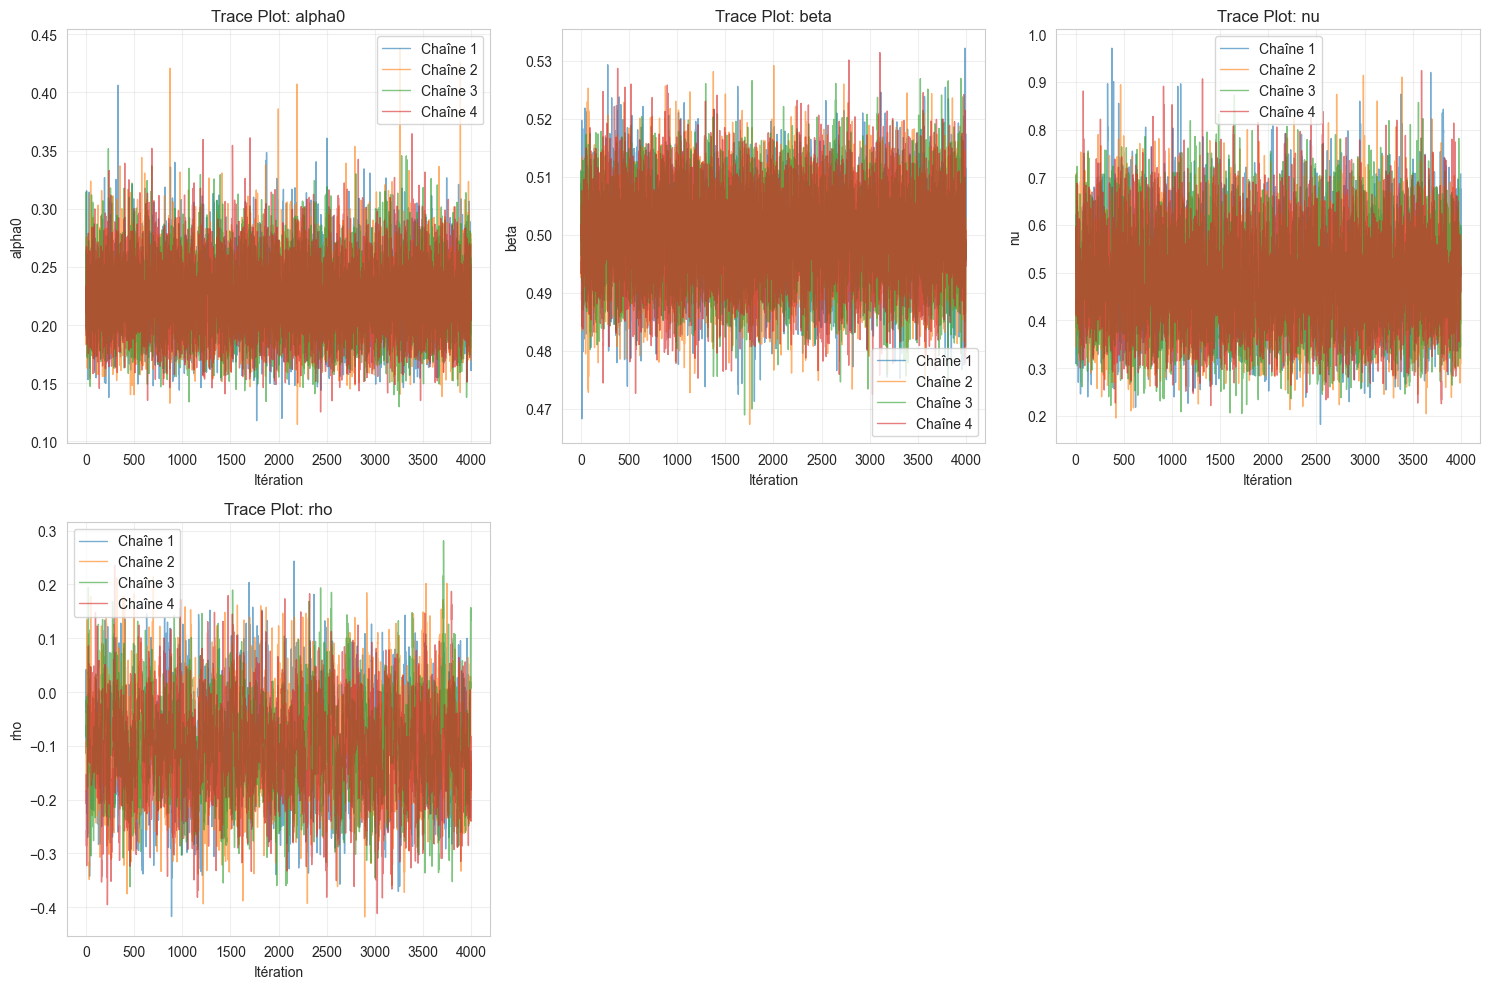

In [7]:
# Vérification visuelle du mélange des chaînes ("hairy caterpillars")
diagnostics.plot_trace()

## 5. Conclusion : Heston vs SABR

L'inférence MCMC sur les modèles de volatilité stochastique met en évidence plusieurs différences fondamentales :

1. **Stabilité Numérique :** Le modèle SABR est plus stable à simuler car sa volatilité suit un mouvement brownien géométrique (strictement positif), contrairement à Heston qui nécessite une réflexion à zéro si la condition de Feller n'est pas respectée.
2. **Horizon de Temps :** L'absence de retour à la moyenne dans SABR fait que la volatilité $\alpha_t$ peut dériver fortement sur de longues périodes ($T > 5$ ans). Il est optimisé pour des maturités plus courtes que Heston.
3. **Complexité d'Inférence :** L'ajout du paramètre d'élasticité $\beta$ rend la surface de probabilité postérieure du SABR très complexe à explorer. La paramétrisation non-centrée avec NUTS s'est avérée indispensable pour forcer la convergence.